- Handling warnings.

In [1]:
import warnings
warnings.filterwarnings("ignore")

- Load modules.

In [2]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
from common_funtions import *
pd.set_option("display.float_format", "{:.6f}".format)

- Import datasets of clustering results and metrics.

In [9]:
orig_clustering = pd.read_csv("../data/clustering_original.csv", index_col = 0)
pca_clustering = pd.read_csv("../data/clustering_pca.csv", index_col = 0)
tsne_2_clustering = pd.read_csv("../data/clustering_tsne_2.csv", index_col = 0)
tsne_3_clustering = pd.read_csv("../data/clustering_tsne_3.csv", index_col = 0)
umap_2_clustering = pd.read_csv("../data/clustering_umap_2.csv", index_col = 0)
umap_3_clustering = pd.read_csv("../data/clustering_umap_3.csv", index_col = 0)

In [10]:
print(orig_clustering.columns)

Index(['id_test', 'name_method', 'silhouette_score', 'davies_bouldin_score',
       'calinski_harabasz_score', 'n_labels', 'proportion_labels', 'threshold',
       'silhouette_score_n', 'davies_bouldin_score_n',
       'calinski_harabasz_score_n', 'consensus_clustering_score'],
      dtype='object')


In [11]:
orig_clustering.insert(0, "input", "original")
pca_clustering.insert(0, "input", "pca")
tsne_2_clustering.insert(0, "input", "tsne_2d")
tsne_3_clustering.insert(0, "input", "tsne_3d")
umap_2_clustering.insert(0, "input", "umap_2d")
umap_3_clustering.insert(0, "input", "umap_3d")

In [13]:
orig_clustering["assay"] = orig_clustering["input"] + "_" + orig_clustering["id_test"]
pca_clustering["assay"] = pca_clustering["input"] + "_" + pca_clustering["id_test"]
tsne_2_clustering["assay"] = tsne_2_clustering["input"] + "_" + tsne_2_clustering["id_test"]
tsne_3_clustering["assay"] = tsne_3_clustering["input"] + "_" + tsne_3_clustering["id_test"]
umap_2_clustering["assay"] = umap_2_clustering["input"] + "_" + umap_2_clustering["id_test"]
umap_3_clustering["assay"] = umap_3_clustering["input"] + "_" + umap_3_clustering["id_test"]

In [15]:
clustering_results = pd.concat([orig_clustering, pca_clustering, tsne_2_clustering, tsne_3_clustering, umap_2_clustering, umap_3_clustering], ignore_index = True)


In [18]:
print(clustering_results.shape)
clustering_results.head(2)

(1324, 14)


,input,id_test,name_method,silhouette_score,davies_bouldin_score,calinski_harabasz_score,n_labels,proportion_labels,threshold,silhouette_score_n,davies_bouldin_score_n,calinski_harabasz_score_n,consensus_clustering_score,assay
0,original,spectral_10_rbf,SpectralClustering,0.045550,2.835658,3.202025,10.000000,"{np.int32(0): np.float64(15.93), np.int32(1): ...",1,1.000000,0.000000,0.438371,0.531511,original_spectral_10_rbf
1,original,spectral_9_rbf,SpectralClustering,0.039995,2.986466,3.263602,9.000000,"{np.int32(0): np.float64(8.85), np.int32(1): n...",1,0.852020,0.034783,0.464113,0.469607,original_spectral_9_rbf


In [19]:
clustering_results.to_csv("../data/clustering_results.csv", index = False)

In [22]:
input_labels = {
    "original": "Original coordinates",
    "pca": "PCA (50)",
    "tsne_2d": "t-SNE 2D",
    "tsne_3d": "t-SNE 3D",
    "umap_2d": "UMAP 2D",
    "umap_3d": "UMAP 3D"
}

clustering_results["input"] = clustering_results["input"].replace(input_labels)

In [32]:
clustering_results.columns

Index(['input', 'id_test', 'name_method', 'silhouette_score',
       'davies_bouldin_score', 'calinski_harabasz_score', 'n_labels',
       'proportion_labels', 'threshold', 'silhouette_score_n',
       'davies_bouldin_score_n', 'calinski_harabasz_score_n',
       'consensus_clustering_score', 'assay'],
      dtype='object')

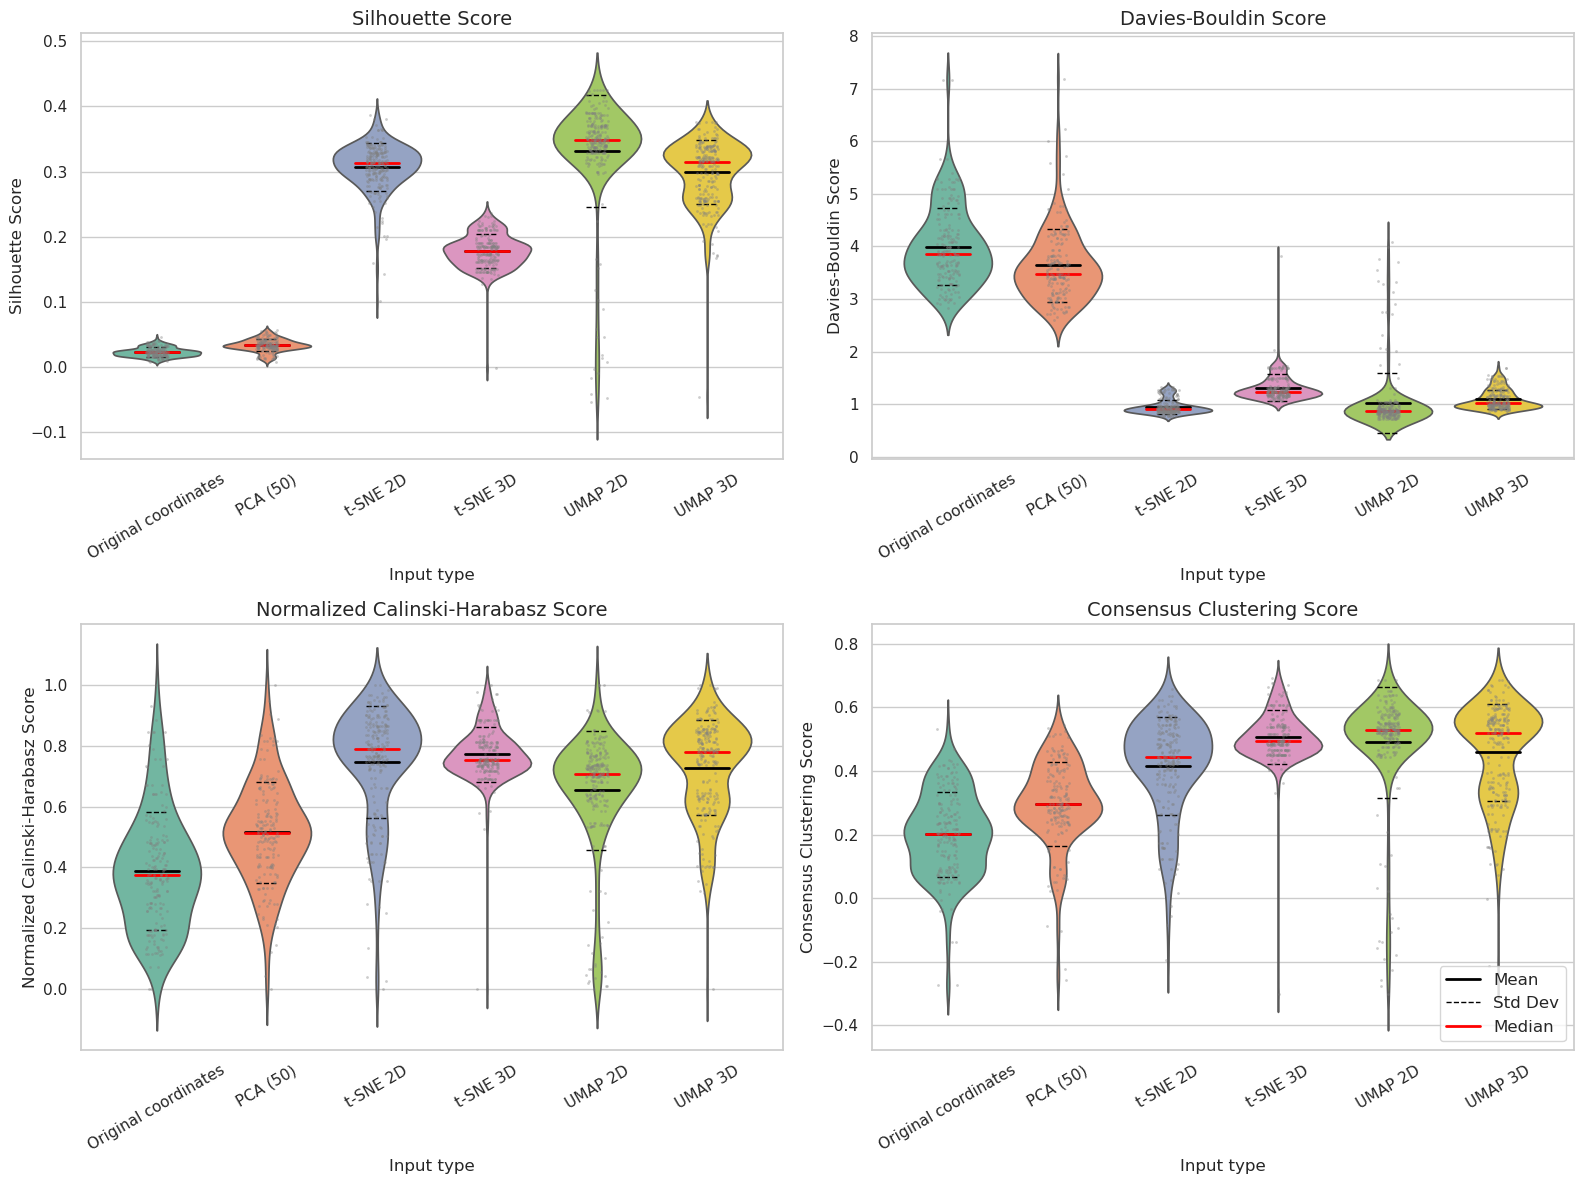

In [55]:
# Set style
sns.set(style = "whitegrid")

# Create a list of the metrics to plot
metrics = [
    ('silhouette_score', 'Silhouette Score'),
    ('davies_bouldin_score', 'Davies-Bouldin Score'),
    ('calinski_harabasz_score_n', 'Normalized Calinski-Harabasz Score'),
    ('consensus_clustering_score', 'Consensus Clustering Score')
]

# Define order for the input methods
input_order = [
    "Original coordinates",
    "PCA (50)",
    "t-SNE 2D",
    "t-SNE 3D",
    "UMAP 2D",
    "UMAP 3D"
]

# Set up the figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Loop through metrics and plot each in a subplot
for ax, (metric_col, metric_name) in zip(axes, metrics):
    # Violin plot
    sns.violinplot(
        data = clustering_results,
        x = "input",
        y = metric_col,
        order = input_order,
        ax = ax,
        inner = None,
        palette = "Set2"
    )
    
    # Add a strip plot on top (the 'cloud' in raincloud)
    sns.stripplot(
        data = clustering_results,
        x = "input",
        y = metric_col,
        order = input_order,
        ax = ax,
        color = 'grey',
        size = 2,
        jitter = True,
        dodge = True,
        alpha = 0.4
    )

    # Add mean, std, and median line markers
    for i, input_type in enumerate(input_order):
        data_subset = clustering_results[clustering_results['input'] == input_type][metric_col]
        mean = data_subset.mean()
        std = data_subset.std()
        median = data_subset.median()

        # Plot mean line (black solid)
        ax.plot([i - 0.2, i + 0.2], [mean, mean], color = 'black', linewidth = 2,
                label = 'Mean' if i == 0 else "")

        # Plot std lines (black dashed)
        ax.plot([i - 0.1, i + 0.1], [mean + std, mean + std], color = 'black', linewidth = 1,
                linestyle = 'dashed', label = 'Std Dev' if i == 0 else "")
        ax.plot([i - 0.1, i + 0.1], [mean - std, mean - std], color = 'black', linewidth = 1,
                linestyle = 'dashed')

        # Plot median line (red solid)
        ax.plot([i - 0.2, i + 0.2], [median, median], color = 'red', linewidth = 2,
                linestyle = '-', label = 'Median' if i == 0 else "")

        ax.set_title(metric_name, fontsize = 14)
        ax.set_xlabel("Input type", fontsize = 12)
        ax.set_ylabel(metric_name, fontsize = 12)
        ax.tick_params(axis = 'x', rotation = 30)
        
    if ax == axes[3]:
        ax.legend(loc = 'lower right', fontsize = 12)


# Adjust layout
plt.tight_layout()
plt.savefig("../figures/metric_comparison.png", dpi = 300, transparent = True, bbox_inches = "tight")
plt.show()

In [41]:
clustering_results.shape

(1324, 16)

In [33]:
# Add binary columns for selecting the top 5% based on the intersection among:
# silhouette_score, davies_bouldin_score, and calinski_harabasz_score; and
# the top 5% based on the consensus_clustering_score.

clustering_results["top5_all_metrics"] = (
    (clustering_results["silhouette_score"] >= np.percentile(clustering_results["silhouette_score"], 95)) &
    (clustering_results["davies_bouldin_score"] <= np.percentile(clustering_results["davies_bouldin_score"], 5)) &
    (clustering_results["calinski_harabasz_score"] >= np.percentile(clustering_results["calinski_harabasz_score"], 95))
    )

clustering_results["top5_consensus"] = (
    clustering_results["consensus_clustering_score"] >= np.percentile(clustering_results["consensus_clustering_score"], 95)
    )

In [34]:
clustering_results.to_csv("../data/clustering_results.csv", index = False)

In [42]:
print(int(clustering_results["top5_all_metrics"].sum()))
print(int(clustering_results["top5_consensus"].sum()))

16
68


In [43]:
# Get assays in each group
assays_top5_all_metrics = set(clustering_results.loc[clustering_results["top5_all_metrics"], "assay"])
assays_top5_consensus = set(clustering_results.loc[clustering_results["top5_consensus"], "assay"])

# Compute the overlap
overlap_assays = assays_top5_all_metrics & assays_top5_consensus

# Print summary
print(f"Number of assays in top5_all_metrics: {len(assays_top5_all_metrics)}")
print(f"Number of assays in top5_consensus: {len(assays_top5_consensus)}")
print(f"Number of overlapping assays: {len(overlap_assays)}")

Number of assays in top5_all_metrics: 16
Number of assays in top5_consensus: 68
Number of overlapping assays: 10


In [48]:
assays_top5_all_metrics

{'umap_2d_affinity_0.5_default',
 'umap_2d_affinity_0.7_default',
 'umap_2d_affinity_0.9_default',
 'umap_2d_agglomerative_10_manhattan_average',
 'umap_2d_birch_9_0.7_100',
 'umap_2d_birch_9_0.7_25',
 'umap_2d_birch_9_0.7_50',
 'umap_2d_birch_9_0.7_75',
 'umap_2d_kmeans_8_elkan',
 'umap_2d_kmeans_8_lloyd',
 'umap_2d_kmeans_9_elkan',
 'umap_2d_kmeans_9_lloyd',
 'umap_2d_spectral_10_nearest_neighbors',
 'umap_2d_spectral_8_nearest_neighbors',
 'umap_2d_spectral_8_rbf',
 'umap_2d_spectral_9_nearest_neighbors'}

In [49]:
clustering_results["top2_5_consensus"] = (
    clustering_results["consensus_clustering_score"] >= np.percentile(clustering_results["consensus_clustering_score"], 97.5)
    )

In [51]:
assays_top2_5_consensus = set(clustering_results.loc[clustering_results["top2_5_consensus"], "assay"])

print(len(assays_top5_all_metrics & assays_top2_5_consensus))

6


In [52]:
len(assays_top2_5_consensus)

34

In [56]:
assays_top2_5_consensus

{'tsne_2d_spectral_3_nearest_neighbors',
 'tsne_3d_kmeans_4_elkan',
 'tsne_3d_kmeans_4_lloyd',
 'tsne_3d_kmeans_5_elkan',
 'tsne_3d_kmeans_5_lloyd',
 'tsne_3d_kmeans_6_elkan',
 'tsne_3d_kmeans_6_lloyd',
 'tsne_3d_kmeans_7_elkan',
 'tsne_3d_kmeans_7_lloyd',
 'tsne_3d_spectral_4_nearest_neighbors',
 'tsne_3d_spectral_5_nearest_neighbors',
 'tsne_3d_spectral_6_nearest_neighbors',
 'tsne_3d_spectral_7_nearest_neighbors',
 'umap_2d_affinity_0.5_default',
 'umap_2d_affinity_0.7_-50',
 'umap_2d_affinity_0.7_default',
 'umap_2d_affinity_0.9_-50',
 'umap_2d_affinity_0.9_default',
 'umap_2d_kmeans_3_elkan',
 'umap_2d_kmeans_3_lloyd',
 'umap_2d_kmeans_9_elkan',
 'umap_2d_kmeans_9_lloyd',
 'umap_2d_spectral_10_nearest_neighbors',
 'umap_3d_affinity_0.7_-10',
 'umap_3d_affinity_0.9_-10',
 'umap_3d_kmeans_4_elkan',
 'umap_3d_kmeans_4_lloyd',
 'umap_3d_kmeans_5_elkan',
 'umap_3d_kmeans_5_lloyd',
 'umap_3d_spectral_10_nearest_neighbors',
 'umap_3d_spectral_4_rbf',
 'umap_3d_spectral_5_nearest_neighbor